# Convolutional Neural Networks

Slide a filter over an image, verify its arithmetic, and train a small image classifier. The task is to distinguish horizontal and vertical bright bars at varying positions. All images are generated locally; the notebook runs on CPU without downloads.

Read the [companion notes](14_Convolutional_Neural_Networks_Notes.ipynb) for the intuition behind each step.

## Start with the problem this lesson solves

Suppose a camera must distinguish horizontal and vertical bars, but the bar can appear at many positions. Flattening the image into an MLP is possible, yet it does not explicitly reuse the same small pattern detector across locations. A CNN is an ANN designed to share local filters across a grid.

A filter produces a response wherever a local pattern appears. Later layers combine these responses into a decision. Sharing weights reduces the number of learned values and makes evidence reusable across image positions; it does not automatically guarantee invariance to every shift or rotation.

## Connect pixels all the way to a loss and a filter update

Use the small image and hand-chosen filter from the arithmetic example:

$$X=\begin{bmatrix}0&1&0&0\\0&1&0&0\\0&1&0&0\\0&1&0&0\end{bmatrix},\qquad
K=\begin{bmatrix}1&-1\\1&-1\end{bmatrix}.$$

**Inspect every distinct patch.** With stride one and no padding, there are three horizontal positions and three vertical positions. All rows of this image are identical, so every output row has the same calculations:

- Left patch: $0(1)+1(-1)+0(1)+1(-1)=-2$.
- Middle patch: $1(1)+0(-1)+1(1)+0(-1)=2$.
- Right patch: $0(1)+0(-1)+0(1)+0(-1)=0$.

Thus the feature map is $[[-2,2,0],[-2,2,0],[-2,2,0]]$. The filter measures a left-minus-right contrast; the same four weights are reused nine times.

**Turn detected evidence into a score.** ReLU gives $[[0,2,0],[0,2,0],[0,2,0]]$. In this teaching-only classifier, average all nine values: $s=(0+2+0+0+2+0+0+2+0)/9=2/3$. Use fixed class logits $[0,s]$, with class zero meaning horizontal and class one meaning vertical, matching the companion's labels.

Softmax gives $p_{vertical}=e^{2/3}/(e^{2/3}+1)\approx0.660756$. For this vertical image, cross-entropy is $-\ln(0.660756)\approx0.414370$. The loss says the correct class should receive more probability.

**Carry that request back to the shared filter.** The derivative with respect to $s$ is $p_{vertical}-1\approx-0.339244$. Averaging gives each feature-map entry a factor $1/9$. ReLU passes gradients only through the three positive entries here. Each active patch is $[[1,0],[1,0]]$, so the gradient of each left-column filter weight is

$$(-0.339244)\times\frac{1}{9}\times(1+1+1)\approx-0.113081.$$

The right-column weights multiply zeros in these active patches, so their gradients are zero. At SGD rate $0.1$, the updated filter is approximately $[[1.011308,-1],[1.011308,-1]]$. Its positive responses become $2.022616$, the mean becomes about $0.674205$, and the vertical probability increases. One shared update strengthened the detector at all three active positions.

This is one filter, one image, no convolution bias, and a fixed output head so the whole learning calculation fits on the page. It is not the trained two-block CNN below. Training on many horizontal and vertical examples is needed to establish a useful orientation classifier.

## Why the ANN's structure matches this problem

Convolution looks for local patterns, ReLU allows nonlinear combinations, pooling summarizes responses, and the final layer turns learned features into class scores. Backpropagation collects contributions from every position where a shared filter was used. The optimizer then changes the filter once using their combined evidence.

This can help a detector work at several locations without storing an unrelated weight for each location. It can also lose information: pooling discards spatial detail, and padding or stride affects responses near boundaries and after shifts. The companion evaluates independently generated bar images; success on them does not establish performance on real photographs or new image conditions.

## Connect the explanation to the code

`F.conv2d(image, kernel)` reproduces the hand-set filter response. `nn.Conv2d` instead stores trainable filters and optional biases. `MaxPool2d` reduces local grids; `AdaptiveAvgPool2d(1)` returns one mean per channel. The actual CNN's linear head learns two logits, and cross-entropy sends an error signal through that head and both convolution blocks. The miniature above uses a fixed head solely to make the filter gradient completely visible.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import copy
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(13)
torch.set_num_threads(1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## Slide a filter by hand

PyTorch images have shape `(batch, channels, height, width)`. This single-channel image has one bright vertical stripe. The filter subtracts the right column of each patch from the left. PyTorch uses cross-correlation: it does not flip the filter.

Filter response:
 tensor([[-2.,  2.,  0.],
        [-2.,  2.,  0.],
        [-2.,  2.,  0.]])


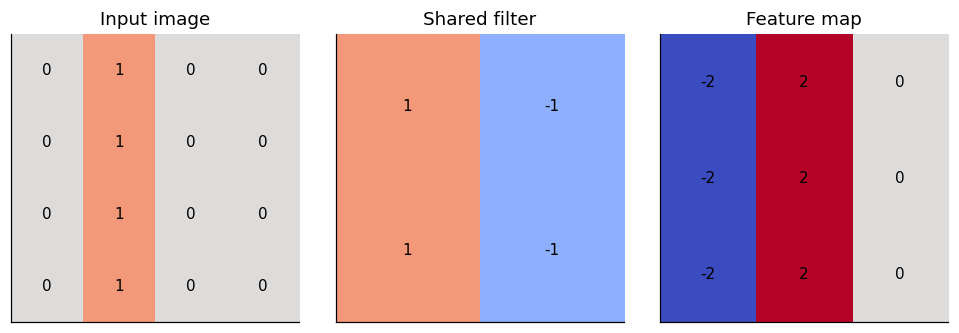

In [2]:
image = torch.tensor([[0., 1., 0., 0.],
                      [0., 1., 0., 0.],
                      [0., 1., 0., 0.],
                      [0., 1., 0., 0.]])[None, None]
kernel = torch.tensor([[1., -1.], [1., -1.]])[None, None]
manual = torch.empty(1, 1, 3, 3)
for row in range(3):
    for col in range(3):
        manual[0, 0, row, col] = (image[0, 0, row:row+2, col:col+2] * kernel[0, 0]).sum()
response = F.conv2d(image, kernel)
expected = torch.tensor([[-2., 2., 0.]]).repeat(3, 1)
torch.testing.assert_close(manual, response)
torch.testing.assert_close(response[0, 0], expected)
print('Filter response:\n', response[0, 0])
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, data, title in zip(axes, [image[0, 0], kernel[0, 0], response[0, 0]],
                           ['Input image', 'Shared filter', 'Feature map']):
    ax.imshow(data, cmap='coolwarm', vmin=-2, vmax=2)
    for (r, c) in [(r, c) for r in range(data.shape[0]) for c in range(data.shape[1])]:
        ax.text(c, r, f'{data[r,c]:.0f}', ha='center', va='center')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## Check padding, stride, channels, and pooling

With dilation one, output height is `floor((H + 2P - K) / S) + 1`; width follows the same rule. Each output filter spans every input channel. A convolution with bias has `C_out × (C_in × K_h × K_w + 1)` learned parameters. ReLU keeps positive responses; max pooling summarizes each local window.

In [3]:
padded = F.conv2d(image, kernel, padding=1, stride=2)
assert padded.shape == (1, 1, 3, 3)
layer = nn.Conv2d(3, 8, kernel_size=3, padding=1)
assert sum(p.numel() for p in layer.parameters()) == 8 * (3 * 3 * 3 + 1)
assert layer(torch.zeros(2, 3, 16, 16)).shape == (2, 8, 16, 16)
patch = torch.tensor([[[[1., 3.], [2., 0.]]]])
torch.testing.assert_close(F.max_pool2d(patch, 2), torch.tensor([[[[3.]]]]))
print('RGB convolution parameters:', sum(p.numel() for p in layer.parameters()))
print('ReLU response:\n', F.relu(response)[0, 0])
print('Maximum in the pooling window:', F.max_pool2d(patch, 2).item())

RGB convolution parameters: 224
ReLU response:
 tensor([[0., 2., 0.],
        [0., 2., 0.],
        [0., 2., 0.]])
Maximum in the pooling window: 3.0


## Generate separate image splits

Class zero is a horizontal bar; class one is vertical. Each 16 × 16 image contains a bar of length eight and thickness two, random position and brightness, and Gaussian noise. Splits use independent random generators and balanced labels. Pixel values are clipped to [0, 1]; there are no fitted preprocessing statistics. Independent samples can share bar positions.

Train / validation / test: 600 160 200


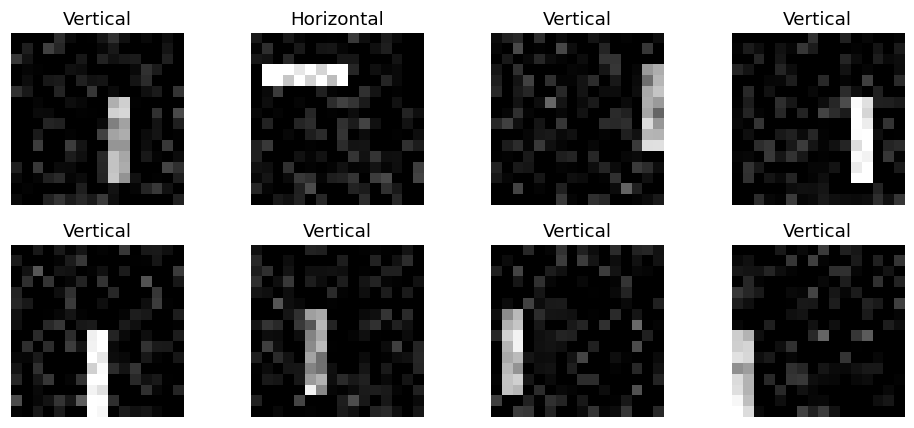

In [4]:
def make_images(count, seed):
    assert count % 2 == 0
    g = torch.Generator().manual_seed(seed)
    labels = torch.arange(count) % 2
    images = 0.12 * torch.randn(count, 1, 16, 16, generator=g)
    for i, label in enumerate(labels):
        height, width = (2, 8) if label.item() == 0 else (8, 2)
        row = torch.randint(0, 17-height, (1,), generator=g).item()
        col = torch.randint(0, 17-width, (1,), generator=g).item()
        brightness = 0.6 + 0.4 * torch.rand((), generator=g)
        images[i, 0, row:row+height, col:col+width] += brightness
    order = torch.randperm(count, generator=g)
    return images.clamp(0, 1)[order], labels[order]

train_x, train_y = make_images(600, 130)
val_x, val_y = make_images(160, 131)
test_x, test_y = make_images(200, 132)
fig, axes = plt.subplots(2, 4, figsize=(9, 4))
for ax, x, y in zip(axes.flat, train_x, train_y):
    ax.imshow(x[0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(['Horizontal', 'Vertical'][y.item()]); ax.axis('off')
plt.tight_layout()
plt.show()
print('Train / validation / test:', len(train_x), len(val_x), len(test_x))

## Build a small CNN

Two learned convolution blocks extract local patterns. Pooling reduces the spatial grid; global average pooling summarizes each final channel into one number. The final linear layer returns two logits. Cross-entropy consumes these logits directly, so there is no softmax in the model.

The parameter count is small because filter weights are reused at every spatial position. Pooling discards some location detail, which is useful for this orientation task but can hurt tasks that require exact coordinates.

In [5]:
torch.manual_seed(13)
model = nn.Sequential(
    nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(16, 2),
)
with torch.no_grad():
    x = train_x[:4]
    for layer in model:
        x = layer(x)
        print(f'{layer.__class__.__name__:20s} {tuple(x.shape)}')
assert x.shape == (4, 2)
assert sum(p.numel() for p in model.parameters()) == 1282
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

Conv2d               (4, 8, 16, 16)
ReLU                 (4, 8, 16, 16)
MaxPool2d            (4, 8, 8, 8)
Conv2d               (4, 16, 8, 8)
ReLU                 (4, 16, 8, 8)
AdaptiveAvgPool2d    (4, 16, 1, 1)
Flatten              (4, 16)
Linear               (4, 2)
Trainable parameters: 1282


## Train and select using validation loss

Each minibatch performs zero-grad → forward → loss → backward → step. We select the lowest validation cross-entropy over 35 fixed epochs. Test images remain unused until the selected snapshot is restored. Training loss is measured during updates; validation loss is measured after each epoch.

Selected epoch: 35
Validation cross-entropy: 0.000377


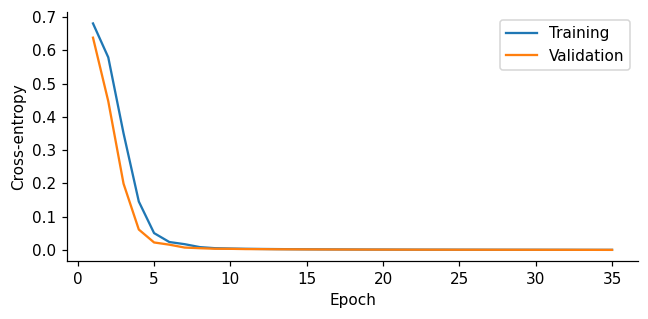

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
shuffle = torch.Generator().manual_seed(133)
train_curve, val_curve = [], []
best_val = float('inf')
for epoch in range(35):
    model.train()
    total_loss = 0.0
    for indices in torch.randperm(len(train_x), generator=shuffle).split(64):
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(train_x[indices]), train_y[indices])
        loss.backward()
        assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in model.parameters())
        optimizer.step()
        total_loss += loss.item() * len(indices)
    model.eval()
    with torch.no_grad():
        validation = F.cross_entropy(model(val_x), val_y).item()
    train_curve.append(total_loss / len(train_x))
    val_curve.append(validation)
    if validation < best_val:
        best_val, best_epoch = validation, epoch + 1
        best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
print('Selected epoch:', best_epoch)
print(f'Validation cross-entropy: {best_val:.6f}')
plt.figure(figsize=(6, 3))
plt.plot(range(1, 36), train_curve, label='Training')
plt.plot(range(1, 36), val_curve, label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy'); plt.legend()
plt.tight_layout(); plt.show()

## Evaluate once on held-out images

Compare to the majority class from the training labels. Rows of the confusion matrix are true labels and columns are predictions. This comparison establishes performance on the bar generator, not superiority to other image classifiers or robustness to real photographs.

Test accuracy: 100.0%; majority baseline: 50.0%
Test cross-entropy: 0.000300
Confusion matrix (horizontal, vertical):
 tensor([[100,   0],
        [  0, 100]])


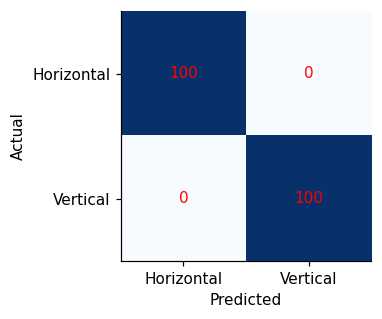

In [7]:
model.eval()
with torch.no_grad():
    test_logits = model(test_x)
    predictions = test_logits.argmax(dim=1)
    test_loss = F.cross_entropy(test_logits, test_y).item()
accuracy = (predictions == test_y).float().mean().item()
majority = train_y.bincount().argmax()
baseline = (test_y == majority).float().mean().item()
confusion = torch.bincount(2 * test_y + predictions, minlength=4).reshape(2, 2)
assert torch.isfinite(test_logits).all()
assert confusion.sum().item() == len(test_y)
print(f'Test accuracy: {accuracy:.1%}; majority baseline: {baseline:.1%}')
print(f'Test cross-entropy: {test_loss:.6f}')
print('Confusion matrix (horizontal, vertical):\n', confusion)
fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(confusion, cmap='Blues')
for r in range(2):
    for c in range(2):
        ax.text(c, r, str(confusion[r,c].item()), ha='center', va='center', color='red')
ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['Horizontal','Vertical'],
       yticklabels=['Horizontal','Vertical'], xlabel='Predicted', ylabel='Actual')
plt.tight_layout(); plt.show()

## Inspect learned feature maps

These are first-layer responses for one held-out image. Bright regions indicate positive activation, not a complete explanation of the decision. Learned channels need not correspond to neatly named concepts.

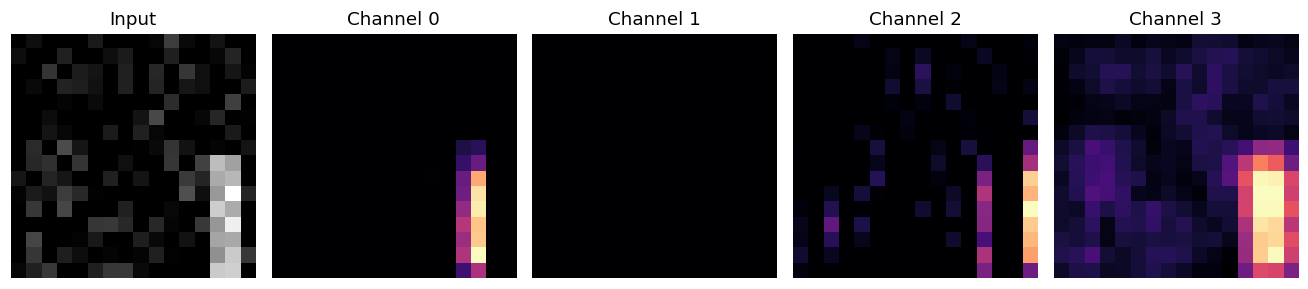

In [8]:
with torch.no_grad():
    maps = F.relu(model[0](test_x[:1]))[0]
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(test_x[0, 0], cmap='gray'); axes[0].set_title('Input')
for i, ax in enumerate(axes[1:]):
    ax.imshow(maps[i], cmap='magma'); ax.set_title(f'Channel {i}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## What this experiment establishes

A small CNN can learn orientation from local pixel patterns while sharing weights across positions. Validation selects the checkpoint and held-out examples measure performance under the same generating process. Rotated bars, new sizes, textured backgrounds, or real images require separate evaluation. Translation invariance is not guaranteed: boundaries, stride, and pooling affect responses. A designed orientation feature could solve this simple task too.